# Problem Formulation

The dataset is an ongoing cardiovascular study consisting of 4,240 middle-aged adults (ages 32–70) from Framingham, Massachusetts. It observes a 10-year follow-up period and analyzes whether patients develop or do not develop coronary heart disease within 10 years based on 15 features, including demographic features and health attributes.

Data can be found here: https://www.kaggle.com/datasets/noeyislearning/framingham-heart-study

**Inferential Question**: What is the mean total cholesterol among adults who develop Coronary Heart Disease within 10 years?

In this scenario, the parameter of interest is the true population mean total cholesterol levels among adults who develop coronary heart disease within 10 years, which will be estimated using the sample cholesterol mean from this dataset where TenYearCHD is 1.

**Predictive Task (Regression)**: Can we accurately predict whether an individual will develop coronary heart disease (target variable) within 10 years using all features? List of features:
- Sex 
- Age
- Education
- Smoking status
- Number of cigarettes smoked per day
- Whether a patient is on blood pressure medication or not    
- Whether a patient has had a stroke before or not
- Whether a patient has a history of hypertension or not
- Diabetes status
- Total cholesterol levels
- Systolic blood pressure levels
- Diastolic blood pressure levels
- Body Mass Index
- Heart rate
- Glucose levels

These tasks differ, as the goal of the inferential task will be to quantify uncertainty regarding total cholesterol levels (the population parameter), whereas the goal of the predictive task will be to maximize out-of-sample predictive performance for a future, unseen observation using F-1 score and PR-AUC as the evaluation metrics and binary cross-entropy as the loss function.


# Data Preprocessing

In [16]:
# Importing libraries
import pandas as pd

# Loading the dataset
df = pd.read_csv('data/framingham_heart_study.csv')

df.head()



,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [17]:
# Checking for missing values

print(df.isnull().sum())
print(df.shape)


male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64
(4240, 16)


In [18]:
# Dropping rows with missing values
df.dropna(inplace=True)
print(df.shape)


(3658, 16)


The new sample size is 3658 patients

In [19]:
# Ensuring numeric data types
print(df.dtypes)

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object


# EDA

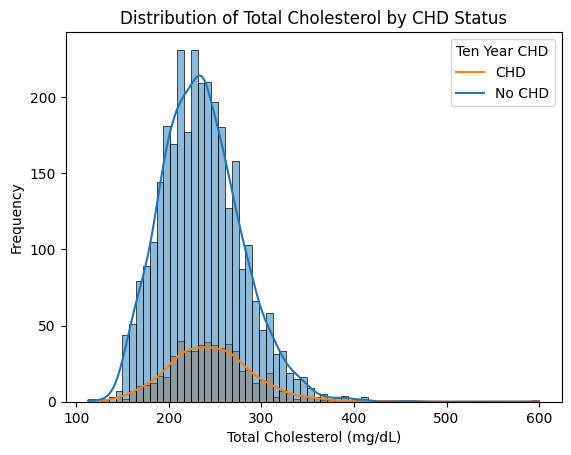

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of total cholesterol for CHD vs non-CHD

sns.histplot(data=df, x='totChol', hue='TenYearCHD', kde=True)
plt.title('Distribution of Total Cholesterol by CHD Status')
plt.xlabel('Total Cholesterol (mg/dL)')
plt.ylabel('Frequency')
plt.legend(title='Ten Year CHD', labels=['CHD', 'No CHD'])
plt.show()

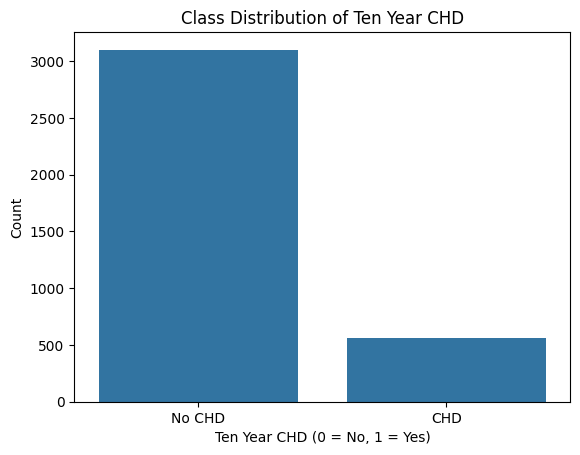

In [21]:
# Plotting class imbalance in the target variable 'TenYearCHD'

sns.countplot(x='TenYearCHD', data=df)
plt.title('Class Distribution of Ten Year CHD')
plt.xlabel('Ten Year CHD (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No CHD', 'CHD'])
plt.show()

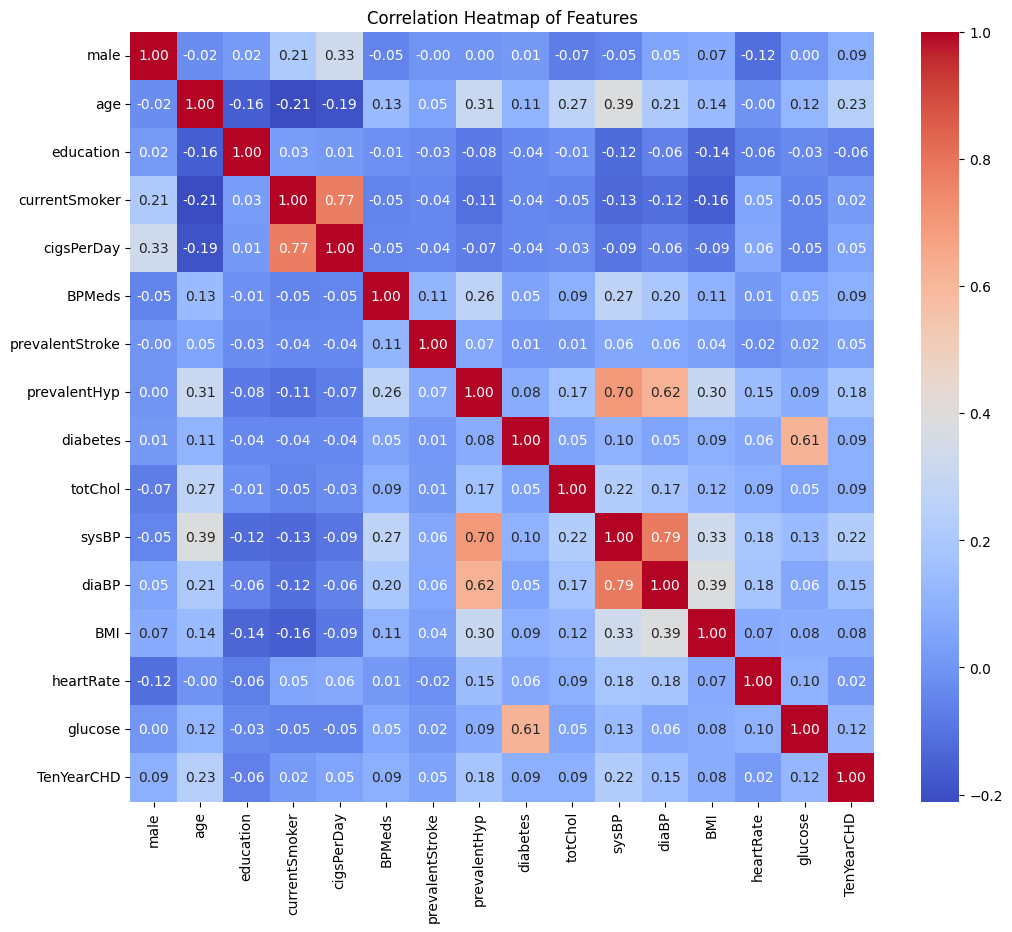

In [22]:
# Correlation heatmap of features
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()

# Likelihood and Estimation

In [23]:
# Extracting total cholesterol values for patients with CHD
chol_chd = df[df['TenYearCHD'] == 1]['totChol']
n = len(chol_chd)
print(f"Number of CHD patients: {n}")

Number of CHD patients: 557


### Likelihood Formulation

We model total cholesterol for CHD patients as i.i.d. Normal ($x_i \sim \mathcal{N}(\mu, \sigma^2)$):

$$L(\mu, \sigma^2 \mid x_1, \ldots, x_n) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right)$$

Maximizing over $\mu$ gives the MLE for the total mean cholesterol level $\hat{\mu} = \bar{x}$, and over $\sigma^2$ gives $\hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2$ with 0 delta degrees of freedom (ddof = 0).

### MLE Computation

In [24]:
# Calculating mean and standard deviation of total cholesterol for CHD patients
mu_mle, sigma = chol_chd.mean(), chol_chd.std(ddof = 0)

print(f"MLE for mean cholesterol: {mu_mle:.4f}")

MLE for mean cholesterol: 246.3501


### Likelihood Visualization

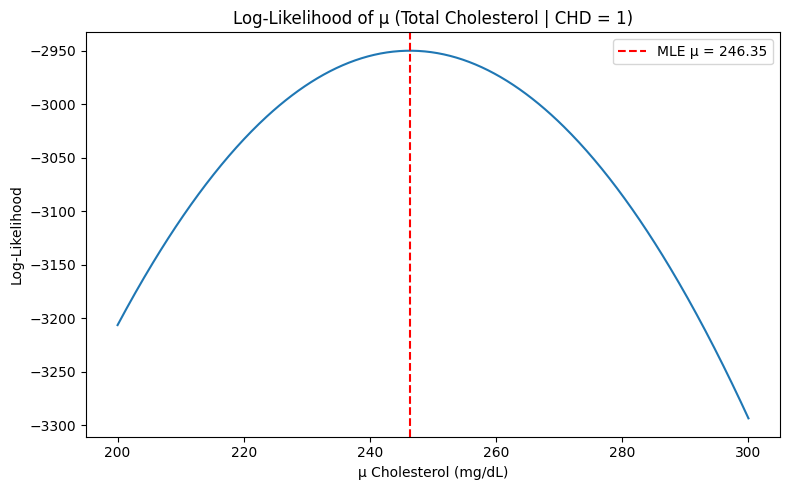

In [25]:
from scipy.stats import norm
import numpy as np

# Range of mu values to evaluate likelihood
mu_range = np.linspace(200, 300, 500)

# Computing log-likelihood for each mu value
log_likelihood = [
    np.sum(norm.logpdf(chol_chd, loc=mu, scale=sigma))
    for mu in mu_range
]

# Plotting log-likelihood as a function of mu
plt.figure(figsize=(8, 5))
plt.plot(mu_range, log_likelihood)
plt.axvline(mu_mle, color='red', linestyle='--', label=f'MLE μ = {mu_mle:.2f}')
plt.title('Log-Likelihood of μ (Total Cholesterol | CHD = 1)')
plt.xlabel('μ Cholesterol (mg/dL)')
plt.ylabel('Log-Likelihood')
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation of Estimator Properties

Given that the distribution of cholesterol values is approximately normal for patients that develop coronary heart disease, the MLE for the mean cholesterol level is the sample mean (246.35 mg/dL), represented by the peak of the above plot. It is an unbiased and a consistent estimator, as increasing sample size will result in the convergence of the sample mean to the true population mean. The MLE for the mean cholesterol level among CHD patients is also the most efficient estimator, as the sample mean has the lowest variance for a normal distribution.

# Frequentist Inference

### Sampling Distribution Reasoning

From the Central Limit Theorem, the sampling distribution of our sample mean is approximately normal, as we have 557 data points which is sufficiently large. The standard error of the mean will represent the variability of the sample mean across repeated samples.

### Theory-based Confidence Interval

In [26]:
from scipy import stats

# Theory-based 95% confidence interval
se = chol_chd.std(ddof=1) / np.sqrt(n)

# Calculating the confidence interval using the t-distribution
ci_lower, ci_upper = stats.t.interval(0.95, df=n-1, loc=mu_mle, scale=se)

print(f"Standard error: {se:.4f} mg/dL")
print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

Standard error: 2.0481 mg/dL
95% CI: (242.3272, 250.3730)


### Bootstrap Confidence Interval

In [27]:
# 95% confidence interval using bootstrap

np.random.seed(42)
n_bootstraps = 10000
bootstrap_means = []

# Generating bootstrap samples and calculating mean for each sample
for _ in range(n_bootstraps):
    sample = chol_chd.sample(n=n, replace=True)
    bootstrap_means.append(sample.mean())

bootstrap_means = np.array(bootstrap_means)

# Calculating 95% confidence interval from bootstrap distribution
ci_lower_boot = np.percentile(bootstrap_means, 2.5)
ci_upper_boot = np.percentile(bootstrap_means, 97.5)

print(f"Bootstrap 95% CI: ({ci_lower_boot:.4f}, {ci_upper_boot:.4f})")

Bootstrap 95% CI: (242.4881, 250.4328)


### Hypothesis Testing

We use a hypothesis test (two-sample t-test) to compare the mean cholesterol levels between patients who did not develop coronary heart disease and patients who did develop coronary heart disease within 10 years.

- **Null Hypothesis (H₀):** $\mu_{CHD} = \mu_{no CHD}$
- **Alternative Hypothesis (H₁):** $\mu_{CHD} > \mu_{no CHD}$

In [28]:
# Filtering total cholesterol values for patients without CHD
chol_no_chd = df[df['TenYearCHD'] == 0]['totChol']

# Two-sample t-test for CHD vs non-CHD cholesterol 
t_stat, p_value = stats.ttest_ind(chol_chd, chol_no_chd, alternative='greater')

print(f"CHD mean: {chol_chd.mean():.4f} mg/dL")
print(f"No CHD mean: {chol_no_chd.mean():.4f} mg/dL")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

CHD mean: 246.3501 mg/dL
No CHD mean: 235.1409 mg/dL
T-statistic: 5.5459
P-value: 0.0000


### Interpretation of results

The confidence level of 95% used in both the theory-based and bootstrap confidence intervals indicates that, if we repeated this sampling procedure many times, 95% of intervals would contain the true population mean cholesterol among adults who develop coronary heart disease within 10 years. The theory-based 95% confidence interval of (242.33, 250.37) mg/dL and the bootstrap 95% confidence interval of (242.4881, 250.4328) mg/dL reflect extremely similar ranges of values for the population mean cholesterol level, quantifying its uncertainty and indicating that our assumptions regarding a normal distribution were correct. 

The p-value of ~0 is less than 0.05, meaning that we reject the null hypothesis, as evidence supports the mean cholesterol levels for patients who develop coronary heart disease within 10 years to be greater than mean cholesterol levels for those who do not. The T-statistic of ~ 5.55 indicates that the observed data would be very unlikely to occur if the null hypothesis were true, suggesting statistical significance in the alternative hypothesis. 